<a href="https://colab.research.google.com/github/Daumi-lab08/Analisis-Deret-Waktu/blob/main/Prak_ADW_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [43]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1037)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5*37
beta0 = 10+37
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


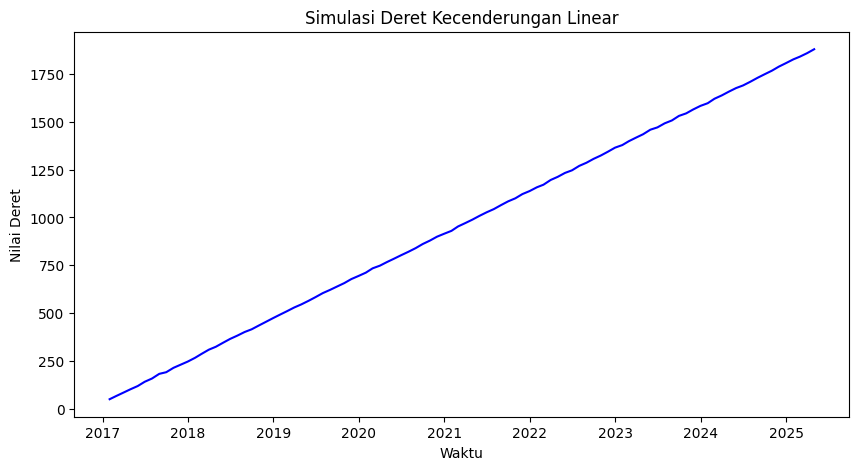

In [44]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

Berdasarkan plot deret waktu, nilai deret menunjukkan kecenderungan meningkat secara linear dari waktu ke waktu. Pengamatan pada periode yang berdekatan juga memiliki nilai yang relatif berdekatan karena deret mengikuti pola kenaikan yang konsisten. Hasil perhitungan menunjukkan korelasi antara waktu dan nilai deret sebesar 1,0000, yang menunjukkan hubungan positif yang sangat kuat. Artinya, semakin bertambah waktu, nilai deret cenderung semakin meningkat. Namun, nilai korelasi tersebut menggambarkan hubungan antara waktu dan nilai deret, sehingga korelasi antar-pengamatan secara langsung perlu dilihat menggunakan korelasi lag atau fungsi autokorelasi (ACF).

In [45]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [46]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.327e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.64e-237
Time:                        13:16:20   Log-Likelihood:                -216.15
No. Observations:                 100   AIC:                             436.3
Df Residuals:                      98   BIC:                             441.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           47.1669      0.421    111.942   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Apakah model regresi yang dipaskan sudah bagus?

Hasil regresi menghasilkan dugaan intersep sebesar $\hat{\beta}_0 = 47.1669$ dan dugaan koefisien waktu sebesar $\hat{\beta}_1 = 18.4965$. Nilai dugaan tersebut sangat dekat dengan parameter asli yang digunakan dalam simulasi, yaitu $\beta_0 = 47$ dan $\beta_1 = 18.5$.

Model regresi yang diperoleh adalah:

$\hat{Y}_t = 47.1669 + 18.4965t$

Koefisien waktu yang positif menunjukkan bahwa nilai deret memiliki kecenderungan meningkat. Setiap kenaikan satu periode waktu diikuti oleh peningkatan nilai deret rata-rata sekitar 18,4965 satuan.

Nilai $R^2 = 1.000$ menunjukkan bahwa hampir seluruh keragaman nilai deret dapat dijelaskan oleh waktu melalui model linear. Hasil ini sesuai dengan proses pembangkitan data yang menggunakan kecenderungan linear dengan tambahan galat acak yang relatif kecil. Koefisien waktu juga memiliki nilai $p < 0.001$, sehingga terdapat kecenderungan linear yang signifikan antara waktu dan nilai deret.

Nilai Durbin-Watson sebesar 1,881 cukup dekat dengan 2, sehingga residual tidak menunjukkan indikasi autokorelasi orde pertama yang kuat. Selain itu, nilai probabilitas Jarque-Bera sebesar 0,878 dan Omnibus sebesar 0,759 lebih besar dari 0,05. Hasil tersebut menunjukkan bahwa tidak terdapat bukti yang cukup bahwa residual menyimpang dari distribusi normal.

Secara keseluruhan, model regresi linear sudah sesuai untuk menggambarkan kecenderungan deret hasil simulasi. Hal ini terlihat dari nilai parameter dugaan yang sangat dekat dengan parameter asli, nilai $R^2$ yang sangat tinggi, serta hasil pemeriksaan residual yang tidak menunjukkan masalah yang berarti.

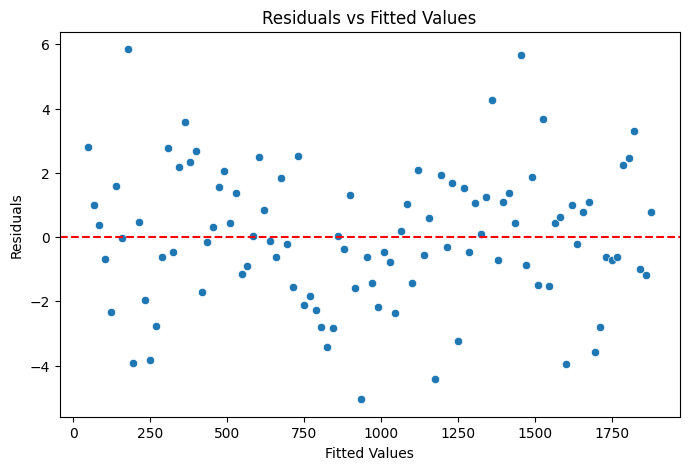

In [47]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

Berdasarkan plot Residuals vs Fitted Values, titik-titik residual terlihat menyebar di sekitar garis nol tanpa membentuk pola tertentu yang jelas. Residual juga memiliki nilai positif dan negatif pada hampir seluruh rentang nilai fitted.

Pola penyebaran residual tidak menunjukkan bentuk mengerucut atau melebar secara sistematis. Hal ini memberikan indikasi bahwa ragam residual relatif konstan atau asumsi homoskedastisitas cukup terpenuhi. Selain itu, tidak terlihat pola lengkung yang kuat pada residual, sehingga hubungan linear antara waktu dan nilai deret masih cukup sesuai.

Meskipun terdapat beberapa residual dengan nilai yang relatif besar, secara umum titik-titik masih tersebar secara acak di sekitar nol. Oleh karena itu, berdasarkan plot residual terhadap fitted values, tidak terlihat adanya pelanggaran asumsi model regresi linear yang cukup kuat.

In [48]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.6348


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

Berdasarkan uji Breusch-Pagan diperoleh $p\text{-value} = 0.6348$. Karena $p\text{-value} > 0.05$, maka $H_0$ tidak ditolak. Hal ini menunjukkan bahwa tidak terdapat indikasi heteroskedastisitas pada residual.

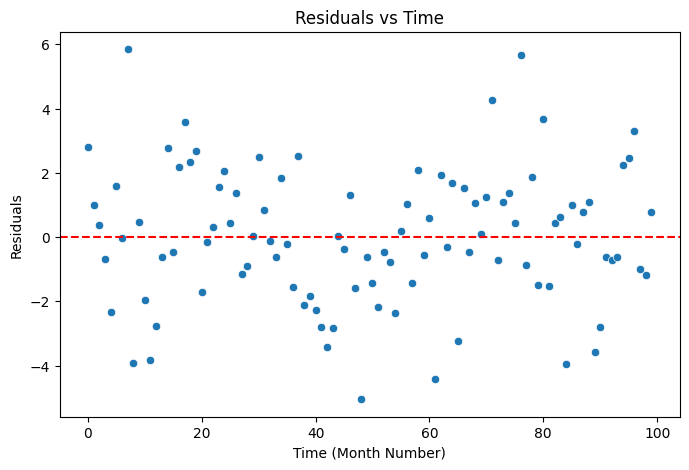

In [49]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

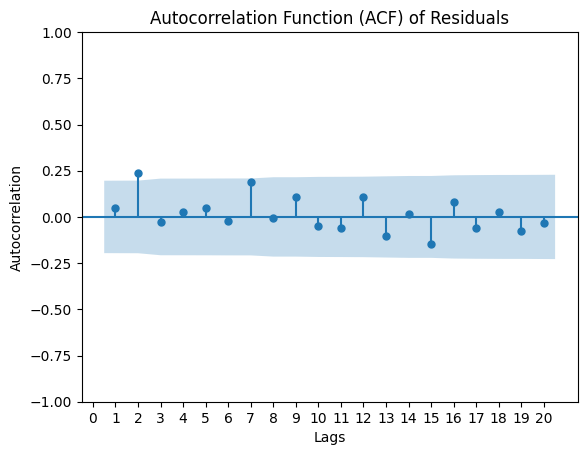

In [50]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

Berdasarkan plot Residuals vs Time, residual terlihat menyebar secara acak di sekitar nilai nol dan tidak menunjukkan pola, tren, atau kecenderungan tertentu terhadap waktu. Penyebaran residual juga relatif stabil sepanjang waktu. Secara visual, kondisi ini menunjukkan bahwa residual tidak memiliki pola sistematis terhadap waktu.

Berdasarkan plot ACF residual, sebagian besar nilai autokorelasi pada lag 1 sampai lag 20 berada di dalam batas kepercayaan 95% dan tidak membentuk pola tertentu. Namun, pada lag ke-2 terdapat nilai autokorelasi yang sedikit melewati batas kepercayaan. Hal ini menunjukkan adanya indikasi autokorelasi residual pada lag ke-2, tetapi pola tersebut tidak terlihat secara konsisten pada lag lainnya.

Secara keseluruhan, plot ACF tidak menunjukkan pola autokorelasi yang kuat atau sistematis pada residual. Meskipun demikian, adanya autokorelasi pada lag ke-2 perlu diperiksa lebih lanjut menggunakan uji Ljung-Box untuk mengetahui apakah autokorelasi residual secara bersama-sama signifikan secara statistik.

In [51]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.258899   0.610878
2    6.212745   0.044763
3    6.307066   0.097590
4    6.389281   0.171902
5    6.628184   0.249793
6    6.692375   0.350235
7   10.638296   0.155193
8   10.645386   0.222613
9   11.884506   0.219899
10  12.150546   0.275107
11  12.564917   0.322710
12  13.873324   0.308871
13  15.072702   0.302836
14  15.094827   0.371703
15  17.699303   0.278804
16  18.498948   0.295499
17  18.949144   0.331459
18  19.054166   0.388495
19  19.793894   0.407075


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

Berdasarkan uji Ljung-Box, sebagian besar lag memiliki nilai $p\text{-value} > 0.05$. Namun, pada lag ke-2 diperoleh $p\text{-value} = 0.0448 < 0.05$, sehingga terdapat indikasi autokorelasi residual hingga lag ke-2.

Berdasarkan hasil uji Ljung-Box, pada lag ke-2 diperoleh $p\text{-value} = 0.044763 < 0.05$, sehingga $H_0$ ditolak pada taraf nyata 5%. Hasil ini menunjukkan bahwa terdapat indikasi autokorelasi residual secara bersama-sama sampai lag ke-2.

Namun, mulai lag ke-3 sampai lag ke-19, seluruh nilai $p\text{-value} > 0.05$, sehingga $H_0$ diterima. Hal ini menunjukkan bahwa secara umum tidak terdapat bukti autokorelasi residual yang kuat atau sistematis pada sebagian besar lag yang diuji.

Hasil tersebut sejalan dengan plot ACF sebelumnya, yaitu sebagian besar autokorelasi berada di dalam batas kepercayaan dan hanya lag ke-2 yang menunjukkan penyimpangan. Oleh karena itu, residual secara umum dapat dikatakan mendekati kondisi tidak berkorelasi, meskipun terdapat indikasi autokorelasi pada lag awal, khususnya sekitar lag ke-2.

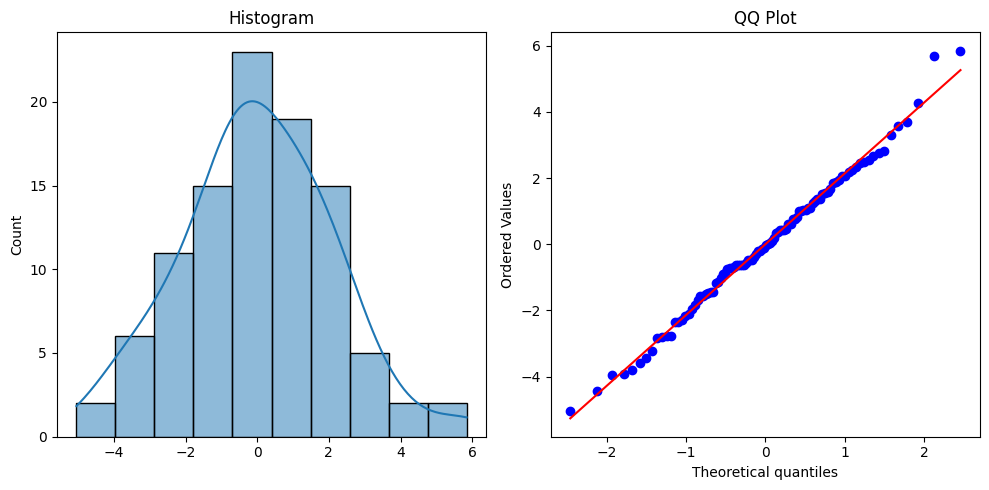

In [52]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

Berdasarkan histogram residual, sebaran residual terlihat cukup simetris di sekitar nilai nol dan membentuk pola yang mendekati distribusi normal. Sebagian besar residual berada di sekitar pusat distribusi, meskipun terdapat beberapa nilai residual yang cukup jauh pada bagian ekor.

Pada QQ Plot, sebagian besar titik residual mengikuti garis diagonal, terutama pada bagian tengah distribusi. Beberapa titik pada bagian ekor terlihat sedikit menyimpang dari garis.

Secara visual, kedua plot menunjukkan bahwa residual dapat dianggap mendekati distribusi normal. Hasil ini juga sejalan dengan uji normalitas sebelumnya, yaitu nilai $p\text{-value}$ Jarque-Bera sebesar 0,878 dan Omnibus sebesar 0,759 yang keduanya lebih besar dari 0,05. Oleh karena itu, tidak terdapat bukti yang cukup untuk menolak asumsi normalitas residual.

In [ ]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9930227394655899, p-value = 0.8894270603453165


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

Berdasarkan uji Shapiro-Wilk diperoleh nilai statistik sebesar 0,9930 dan $p\text{-value}=0,8894$. Karena $p\text{-value}>0,05$, maka $H_0$ tidak ditolak, sehingga residual dapat dianggap berdistribusi normal. Kesimpulan ini sesuai dengan hasil visual pada histogram dan QQ Plot, yang menunjukkan bahwa residual memiliki pola yang mendekati distribusi normal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [53]:
# Menentukan parameter simulasi
np.random.seed(1037)
n_periods = 120
beta_0, beta_1, beta_2= 50+37, 0.5*37, 0.02*37
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

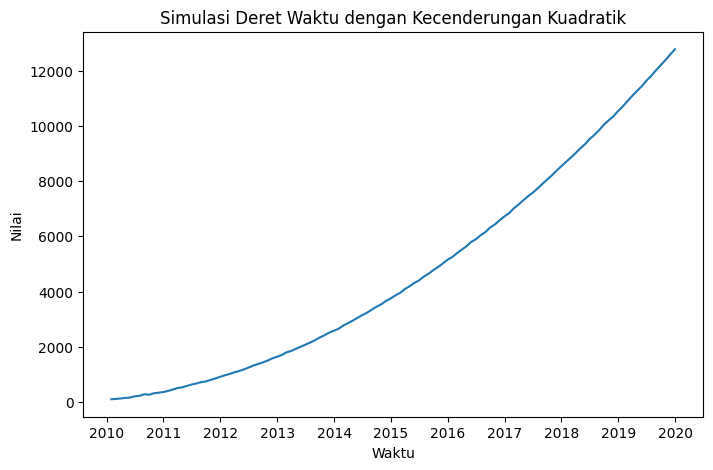

In [54]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?


Berdasarkan plot deret waktu, nilai deret menunjukkan kecenderungan meningkat dari waktu ke waktu dengan pola yang melengkung ke atas. Pada periode awal, peningkatan nilai deret masih relatif kecil, kemudian kenaikannya menjadi semakin besar pada periode-periode berikutnya. Pola ini menunjukkan adanya kecenderungan kuadratik yang positif.

Pola tersebut sesuai dengan model. Nilai $\beta_2$ yang positif menyebabkan laju kenaikan deret semakin besar seiring bertambahnya waktu.

Pada kecenderungan linear, deret meningkat dengan laju yang relatif konstan sehingga pola membentuk garis yang hampir lurus. Sementara itu, pada kecenderungan kuadratik, laju kenaikan tidak konstan tetapi semakin besar dari waktu ke waktu sehingga pola deret membentuk kurva yang semakin menanjak. Dengan demikian, deret kuadratik menunjukkan perubahan kecenderungan yang lebih cepat dibandingkan deret dengan kecenderungan linear.

In [55]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.814e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.40e-300
Time:                        13:45:01   Log-Likelihood:                -450.49
No. Observations:                 120   AIC:                             907.0
Df Residuals:                     117   BIC:                             915.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         89.9713      2.818     31.926      0.0

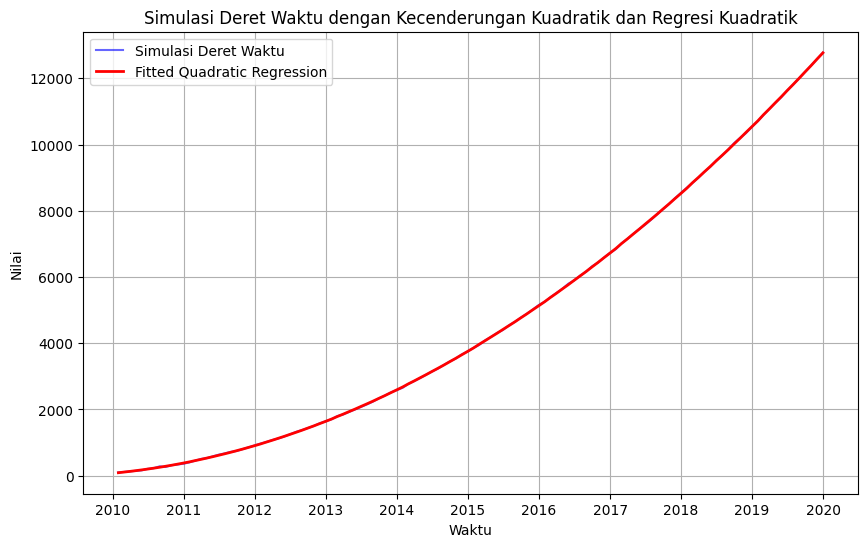

In [56]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

Berdasarkan hasil regresi kuadratik tersebut, parameter hasil pendugaan cukup dekat dengan parameter asli yang digunakan pada simulasi. Nilai parameter asli adalah $\beta_0 = 87$, $\beta_1 = 18.5$, dan $\beta_2 = 0.74$, sedangkan hasil pendugaan diperoleh $\hat{\beta}_0 = 89.9713$, $\hat{\beta}_1 = 18.3687$, dan $\hat{\beta}_2 = 0.7410$.

Model regresi kuadratik yang diperoleh adalah:

$\hat{Y}_t = 89.9713 + 18.3687t + 0.7410t^2$

Koefisien $t^2$ bernilai positif, sehingga pola kecenderungan deret berbentuk kurva yang meningkat dengan laju kenaikan yang semakin besar seiring bertambahnya waktu.

Nilai $R^2 = 1.000$ menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh komponen waktu $t$ dan $t^2$. Selain itu, nilai $p\text{-value} < 0.05$ pada kedua koefisien menunjukkan bahwa komponen linear dan kuadratik signifikan dalam menjelaskan nilai deret. Nilai Durbin-Watson sebesar 1.942 juga mendekati 2, sehingga tidak terdapat indikasi autokorelasi residual yang kuat.

Secara umum, model regresi kuadratik sudah sangat baik dalam menggambarkan kecenderungan deret karena hasil pendugaan parameter mendekati parameter asli dan model mampu menjelaskan hampir seluruh variasi data.

Berdasarkan hasil pengepasan model, nilai Durbin-Watson sebesar 1,942 mendekati 2, sehingga secara awal tidak terdapat indikasi autokorelasi residual yang kuat. Nilai Prob(JB) sebesar 0,788 dan Prob(Omnibus) sebesar 0,662, yang keduanya lebih besar dari 0,05, menunjukkan bahwa residual tidak mengalami penyimpangan yang berarti dari distribusi normal.

Berdasarkan hasil uji Breusch-Pagan diperoleh $p\text{-value} = 0.8194 > 0.05$, sehingga $H_0$ tidak ditolak. Hal ini menunjukkan bahwa tidak terdapat bukti heteroskedastisitas pada residual, sehingga asumsi homoskedastisitas dapat dikatakan terpenuhi.

Berdasarkan uji Ljung-Box pada lag 1 sampai lag 20, seluruh nilai $p\text{-value} > 0.05$. Dengan demikian, $H_0$ tidak ditolak pada seluruh lag yang diuji. Hasil ini menunjukkan bahwa tidak terdapat bukti autokorelasi residual sampai lag ke-20, sehingga asumsi independensi residual dapat dikatakan terpenuhi.

Berdasarkan uji Shapiro-Wilk diperoleh nilai statistik sebesar 0,9913 dan $p\text{-value} = 0.6511 > 0.05$, sehingga $H_0$ tidak ditolak. Artinya, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual menyimpang dari distribusi normal, sehingga asumsi normalitas residual dapat dikatakan terpenuhi.

Secara keseluruhan, hasil pemeriksaan menunjukkan bahwa model regresi kuadratik telah memenuhi asumsi homoskedastisitas, independensi residual, dan normalitas residual. Oleh karena itu, model regresi kuadratik dapat digunakan untuk menggambarkan kecenderungan deret hasil simulasi.

Model regresi kuadratik yang dipaskan terhadap deret sudah tepat. Secara visual, garis hasil regresi kuadratik hampir berimpit dengan deret hasil simulasi, sehingga model mampu mengikuti pola kecenderungan deret dengan baik. Selain itu, nilai $R^2 = 1,000$ menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh komponen waktu $t$ dan $t^2$. Koefisien $t$ dan $t^2$ juga memiliki $p\text{-value} < 0,05$, sehingga keduanya signifikan dalam menjelaskan nilai deret. Hasil pendugaan parameter juga sangat dekat dengan parameter asli yang digunakan pada simulasi. Oleh karena itu, model regresi kuadratik sudah tepat untuk menggambarkan kecenderungan deret tersebut.

Kesimpulannya, cukup bukti untuk mengatakan bahwa model regresi kuadratik sudah tepat karena mampu mengikuti pola deret dengan sangat baik, memiliki $R^2$ yang sangat tinggi, serta menghasilkan dugaan parameter yang dekat dengan parameter asli.


In [59]:
# cek asumsi model regresi kuadratik

from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from scipy.stats import shapiro

# Residual model
resid_quad = model_quad.resid

# 1. Uji Breusch-Pagan
bp_test = het_breuschpagan(resid_quad, model_quad.model.exog)

print("Uji Breusch-Pagan")
print(f"p-value = {bp_test[1]:.4f}")

# Uji Ljung-Box
ljung_quad = acorr_ljungbox(
    resid_quad,
    lags=range(1, 21),
    return_df=True
)

print("\nUji Ljung-Box")
print(ljung_quad)

# 3. Uji Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(resid_quad)

print("\nUji Shapiro-Wilk")
print(f"Statistic = {shapiro_stat:.4f}")
print(f"p-value = {shapiro_p:.4f}")

Uji Breusch-Pagan
p-value = 0.8194

Uji Ljung-Box
      lb_stat  lb_pvalue
1    0.067325   0.795272
2    3.845466   0.146207
3    3.875186   0.275261
4    3.948151   0.413068
5    4.011001   0.547833
6    4.014406   0.674727
7    5.838357   0.558745
8    5.843928   0.664709
9    7.991238   0.535029
10   8.269486   0.602532
11   9.063419   0.616038
12   9.224074   0.683682
13  11.725517   0.550270
14  11.725816   0.628311
15  16.474336   0.351246
16  17.602080   0.347707
17  17.975008   0.390419
18  17.985326   0.456620
19  18.286273   0.503398
20  19.402109   0.495843

Uji Shapiro-Wilk
Statistic = 0.9913
p-value = 0.6511


## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [60]:
# Menentukan parameter simulasi
np.random.seed(1037)
n_periods = 120
beta0, beta1, beta2=50+37,-25*37, -2*37
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


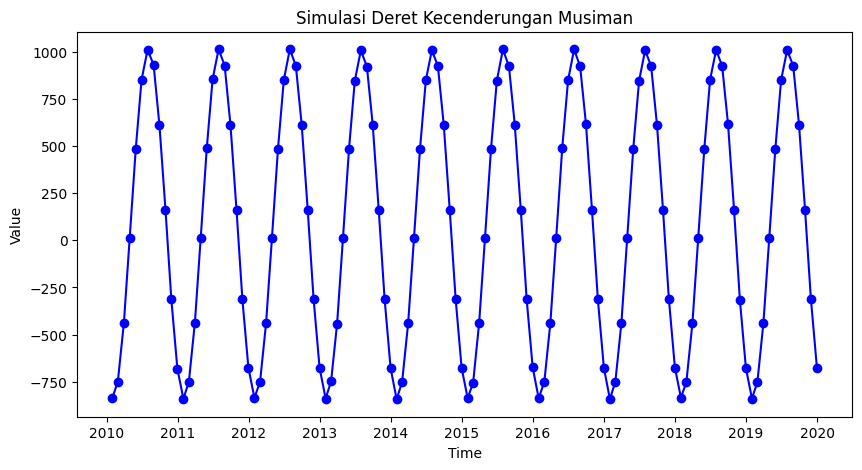

In [61]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Berdasarkan plot deret waktu, terlihat pola naik dan turun yang berulang secara teratur setiap 12 periode. Nilai deret mencapai puncak dan lembah pada pola waktu yang relatif sama dari tahun ke tahun. Besarnya fluktuasi juga relatif stabil dan tidak terlihat adanya kecenderungan meningkat atau menurun dalam jangka panjang. Dengan demikian, deret tersebut menunjukkan pola musiman yang kuat dengan periode musiman 12, sedangkan variasi kecil antarperiode disebabkan oleh adanya noise acak.

In [62]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [63]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [64]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [65]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.013e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.74e-265
Time:                        14:24:34   Log-Likelihood:                -255.99
No. Observations:                 120   AIC:                             536.0
Df Residuals:                     108   BIC:                             569.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -838.6657      0.681  -1231.616      0.0

Bagaimana interpretasi dari hasil tersebut?

Berdasarkan hasil regresi musiman, setiap koefisien bulan menunjukkan rata-rata nilai deret pada bulan tersebut karena model dipaskan tanpa intersep. Nilai deret cenderung meningkat dari awal tahun sampai pertengahan tahun, kemudian menurun kembali menuju akhir tahun.

Nilai rata-rata terendah terjadi pada Januari sebesar -838,6657, sedangkan nilai rata-rata tertinggi terjadi pada Juli sebesar 1011,7069. Setelah mencapai puncak pada Juli, nilai deret mulai menurun pada Agustus hingga Desember. Pola tersebut menunjukkan adanya pola musiman yang berulang dalam periode 12 bulan.

Seluruh koefisien bulan memiliki $p\text{-value} < 0.05$, sehingga masing-masing komponen musiman signifikan dalam menjelaskan nilai deret. Nilai $R^2 = 1.000$ menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh komponen musiman bulanan.

Nilai Durbin-Watson sebesar 1,897 juga mendekati 2, sehingga tidak terlihat adanya indikasi autokorelasi residual yang kuat. Selain itu, nilai Prob(JB) sebesar 0,799 dan Prob(Omnibus) sebesar 0,705 lebih besar dari 0,05, sehingga residual tidak menunjukkan penyimpangan yang berarti dari distribusi normal.

Secara keseluruhan, model regresi dengan dummy musiman sudah mampu menggambarkan pola musiman deret dengan baik. Pola kenaikan dan penurunan nilai antarbulan juga sesuai dengan plot deret sebelumnya yang menunjukkan pola berulang setiap 12 periode.

In [66]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

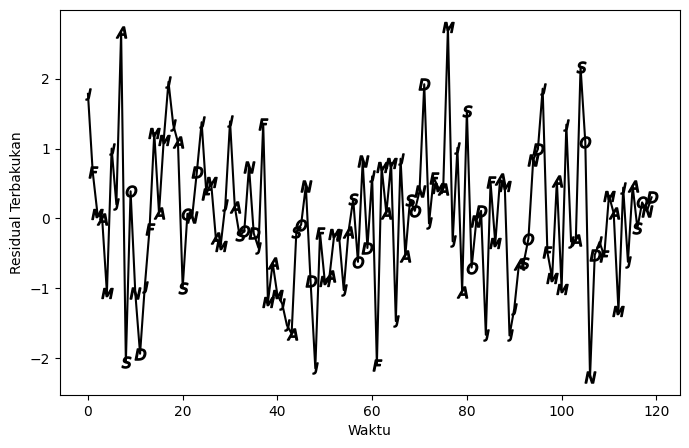

In [67]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


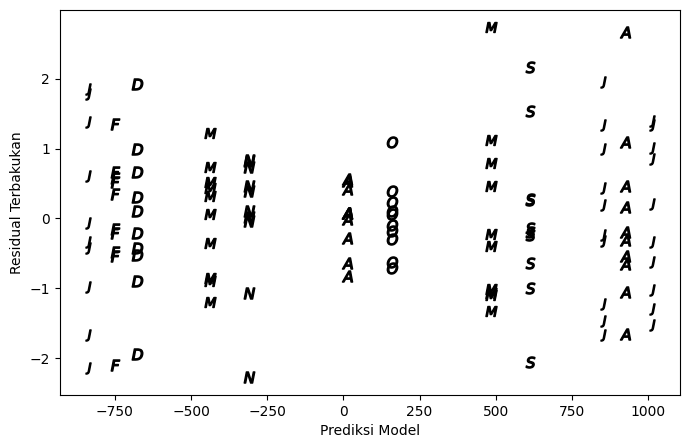

In [68]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

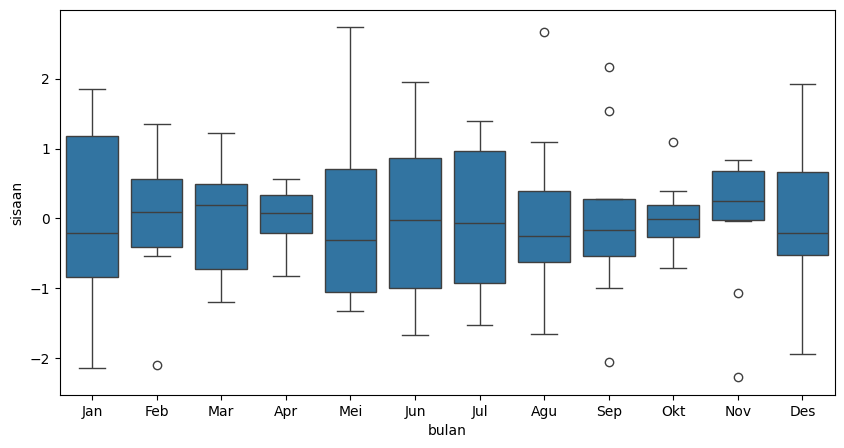

In [69]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

Plot residual terbakukan terhadap waktu menunjukkan bahwa residual menyebar secara acak di sekitar nilai nol dan tidak membentuk pola tertentu sepanjang waktu. Simbol bulan juga tidak membentuk pola berulang yang teratur. Hal ini menunjukkan bahwa pola musiman sudah cukup terakomodasi oleh model dan tidak terlihat adanya pola musiman yang tersisa pada residual.

Plot residual terbakukan terhadap nilai prediksi model menunjukkan bahwa residual tersebar di sekitar nilai nol pada berbagai nilai prediksi dan tidak membentuk pola tertentu, seperti pola mengerucut atau melebar. Setiap kelompok vertikal terbentuk karena masing-masing bulan memiliki nilai prediksi yang sama. Secara visual, tidak terlihat perubahan keragaman residual yang sistematis sehingga tidak terdapat indikasi heteroskedastisitas yang kuat.

Boxplot residual berdasarkan bulan menunjukkan bahwa residual pada setiap bulan secara umum berada di sekitar nilai nol. Sebaran residual antarbulan sedikit berbeda dan terdapat beberapa pencilan, terutama pada beberapa bulan, tetapi tidak terlihat pola perbedaan yang sistematis antarbulan. Hal ini menunjukkan bahwa setelah komponen musiman dimasukkan ke dalam model, tidak terdapat pola musiman yang jelas pada residual.

Ketiga plot secara visual menunjukkan bahwa residual sudah menyebar cukup acak di sekitar nol, tidak menunjukkan pola musiman yang tersisa, dan tidak menunjukkan perubahan keragaman yang sistematis. Dengan demikian, model musiman yang dipaskan secara umum sudah cukup baik dalam menangkap pola musiman pada deret waktu.

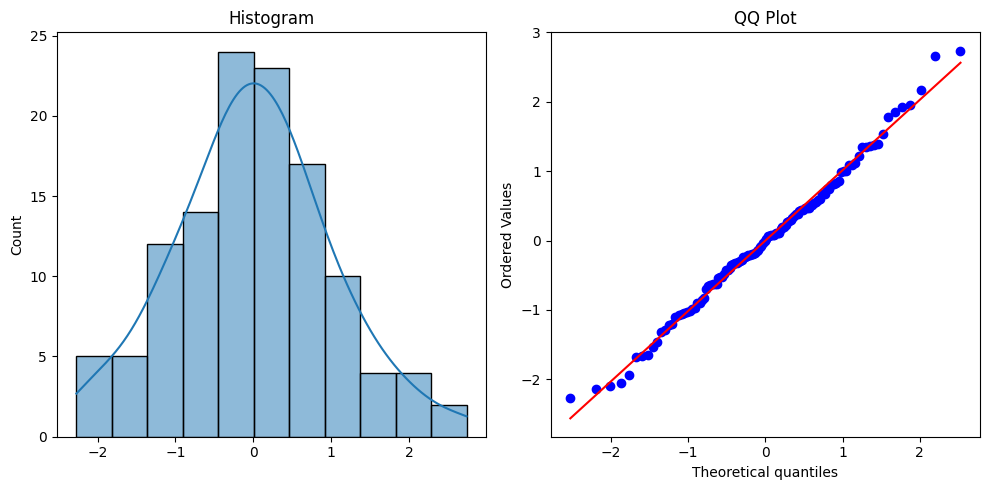

In [71]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

Berdasarkan histogram residual, sebaran residual terlihat cukup simetris dan Berdasarkan histogram residual, sebaran residual terlihat cukup simetris dan mendekati bentuk distribusi normal. Pada QQ Plot, sebagian besar titik residual mengikuti garis diagonal, meskipun terdapat sedikit penyimpangan pada bagian ekor.

Hasil tersebut menunjukkan bahwa secara visual residual mendekati distribusi normal. Jika dikaitkan dengan plot residual sebelumnya, residual juga menyebar cukup acak di sekitar nol dan tidak menunjukkan pola musiman yang tersisa. Dengan demikian, secara visual model musiman yang dipaskan sudah cukup tepat. Namun, pemenuhan asumsi model perlu dikonfirmasi lebih lanjut menggunakan uji statistik.

In [73]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep


from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# Residual model
resid_musiman = musiman.resid


# 1. Uji Breusch-Pagan
# Gunakan 11 dummy bulan + konstanta
X_bp = sm.add_constant(musim.iloc[:, 1:])

bp_test = het_breuschpagan(resid_musiman, X_bp)

print("Uji Breusch-Pagan")
print(f"p-value = {bp_test[1]:.4f}")


# 2. Uji Ljung-Box
ljung_test = acorr_ljungbox(
    resid_musiman,
    lags=range(1, 13),
    return_df=True
)

print("\nUji Ljung-Box")
print(ljung_test)


# 3. Uji Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(resid_musiman)

print("\nUji Shapiro-Wilk")
print(f"Statistic = {shapiro_stat:.4f}")
print(f"p-value = {shapiro_p:.4f}")


# 4. Durbin-Watson
dw = durbin_watson(resid_musiman)

print("\nDurbin-Watson")
print(f"Statistic = {dw:.4f}")


Uji Breusch-Pagan
p-value = 0.3324

Uji Ljung-Box
      lb_stat  lb_pvalue
1    0.175645   0.675143
2    5.138234   0.076603
3    5.214870   0.156723
4    5.219234   0.265533
5    5.493435   0.358666
6    5.494438   0.482129
7    8.105947   0.323344
8    8.154202   0.418554
9   10.187502   0.335520
10  10.332501   0.411822
11  10.740982   0.465211
12  10.762395   0.549384

Uji Shapiro-Wilk
Statistic = 0.9922
p-value = 0.7391

Durbin-Watson
Statistic = 1.8972


Berdasarkan uji Shapiro-Wilk diperoleh nilai statistik sebesar 0.9922 dan $p\text{-value}=0.7391$. Karena $p\text{-value}>0.05$, maka $H_0$ tidak ditolak, sehingga residual dapat dianggap berdistribusi normal.

Berdasarkan uji Breusch-Pagan diperoleh $p\text{-value}=0.3324$. Karena $p\text{-value}>0.05$, maka $H_0$ tidak ditolak, sehingga tidak terdapat indikasi heteroskedastisitas. Dengan demikian, asumsi homoskedastisitas terpenuhi.

Berdasarkan uji Ljung-Box pada lag ke-12 diperoleh nilai $p\text{-value}=0.5494$. Karena $p\text{-value}>0.05$, maka $H_0$ tidak ditolak, sehingga tidak terdapat indikasi autokorelasi residual hingga lag ke-12. Hal ini menunjukkan bahwa pola musiman dengan periode 12 sudah cukup terakomodasi oleh model.

Nilai Durbin-Watson sebesar 1.8972 juga mendekati 2, sehingga mendukung kesimpulan bahwa tidak terdapat indikasi autokorelasi residual orde pertama yang kuat.

Secara keseluruhan, hasil pengujian menunjukkan bahwa residual memenuhi asumsi normalitas, homoskedastisitas, dan independensi. Dengan demikian, model musiman yang dipaskan sudah cukup baik dalam menggambarkan pola musiman pada deret waktu.

In [74]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [75]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.013e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.74e-265
Time:                        14:41:39   Log-Likelihood:                -255.99
No. Observations:                 120   AIC:                             536.0
Df Residuals:                     108   BIC:                             569.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -838.6657      0.681  -1231.616      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

Pada model tanpa intersep, seluruh 12 bulan dimasukkan sebagai variabel dummy.

Model tanpa intersep dapat dituliskan sebagai:

$Y_t = \beta_0 + \beta_1D_{Feb} + \beta_2D_{Mar} + \cdots + \beta_{11}D_{Des} + \varepsilon_t$

Pada model tanpa intersep, setiap koefisien bulan menunjukkan dugaan rata-rata nilai deret pada bulan tersebut. Sementara itu, pada model dengan intersep, Januari digunakan sebagai kategori acuan. Nilai intersep sebesar -838,6657 menunjukkan dugaan rata-rata nilai deret pada bulan Januari, sedangkan koefisien bulan lainnya menunjukkan selisih rata-rata nilai deret bulan tersebut terhadap Januari.

Sebagai contoh, koefisien Februari sebesar 87,3942 menunjukkan bahwa rata-rata nilai deret pada Februari lebih tinggi 87,3942 satuan dibandingkan Januari. Dengan demikian, dugaan rata-rata Februari adalah:

$-838,6657 + 87,3942 = -751,2715$

Koefisien Juli sebesar 1850,3726 menunjukkan bahwa rata-rata nilai deret pada Juli lebih tinggi 1850,3726 satuan dibandingkan Januari. Dengan demikian, dugaan rata-rata Juli adalah:

$-838,6657 + 1850,3726 = 1011,7069$

Cara yang sama berlaku untuk bulan-bulan lainnya. Jika nilai intersep dijumlahkan dengan masing-masing koefisien bulan, hasilnya sama dengan koefisien yang diperoleh pada model tanpa intersep. Oleh karena itu, kedua model menghasilkan nilai prediksi yang sama, tetapi memiliki cara interpretasi parameter yang berbeda.

Seluruh koefisien bulan memiliki $p\text{-value} < 0,05$. Pada model dengan intersep, hasil tersebut menunjukkan bahwa rata-rata masing-masing bulan berbeda secara signifikan dari rata-rata bulan Januari sebagai kategori acuan. Nilai $R^2 = 1,000$ juga sama dengan model tanpa intersep, sehingga kedua model memiliki kemampuan yang sama dalam menjelaskan pola musiman deret.

Model dengan intersep juga memenuhi asumsi regresi. Nilai Durbin-Watson sebesar 1,897 mendekati 2. Hasil uji Breusch-Pagan sebelumnya memberikan $p\text{-value} = 0,3324 > 0,05$, sehingga tidak terdapat indikasi heteroskedastisitas. Uji Ljung-Box sampai lag ke-12 menghasilkan seluruh $p\text{-value} > 0,05$, sehingga tidak terdapat indikasi autokorelasi residual. Selain itu, uji Shapiro-Wilk menghasilkan $p\text{-value} = 0,7391 > 0,05$, sehingga tidak terdapat bukti bahwa residual menyimpang dari distribusi normal.

Model dengan intersep dan tanpa intersep sama-sama dapat digunakan untuk menggambarkan pola musiman. Perbedaannya hanya terletak pada interpretasi koefisien. Model tanpa intersep memberikan rata-rata masing-masing bulan secara langsung, sedangkan model dengan intersep menggunakan Januari sebagai bulan acuan dan koefisien bulan lainnya menunjukkan perbedaannya terhadap Januari.



Model dengan intersep memenuhi asumsi regresi. Model dengan intersep memiliki nilai fitted dan residual yang sama dengan model tanpa intersep, sehingga hasil pemeriksaan asumsi residual sebelumnya juga berlaku. Uji Shapiro-Wilk menghasilkan $p\text{-value}=0.7391>0.05$, sehingga residual dapat dianggap berdistribusi normal. Uji Breusch-Pagan menghasilkan $p\text{-value}=0.3324>0.05$, sehingga tidak terdapat indikasi heteroskedastisitas. Uji Ljung-Box pada lag ke-12 menghasilkan $p\text{-value}=0.5494>0.05$, sehingga tidak terdapat indikasi autokorelasi residual hingga lag ke-12. Nilai Durbin-Watson sebesar 1,897 juga mendekati 2.

In [76]:
# uji asumsi model dengan intersep
# Uji asumsi model dengan intersep

# 1. Uji normalitas residual: Shapiro-Wilk
from scipy.stats import shapiro

shapiro_test_int = shapiro(musiman_int.resid)

print("Shapiro-Wilk Test")
print(f"Statistic = {shapiro_test_int.statistic:.4f}")
print(f"P-value = {shapiro_test_int.pvalue:.4f}")


# 2. Uji homoskedastisitas: Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test_int = het_breuschpagan(
    musiman_int.resid,
    musiman_int.model.exog
)

print("\nBreusch-Pagan Test")
print(f"LM Statistic = {bp_test_int[0]:.4f}")
print(f"P-value = {bp_test_int[1]:.4f}")


# 3. Uji autokorelasi residual: Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_int = acorr_ljungbox(
    musiman_int.resid,
    lags=[12],
    return_df=True
)

print("\nLjung-Box Test")
print(ljung_box_int)

Shapiro-Wilk Test
Statistic = 0.9922
P-value = 0.7391

Breusch-Pagan Test
LM Statistic = 12.4266
P-value = 0.3324

Ljung-Box Test
      lb_stat  lb_pvalue
12  10.762395   0.549384


Berdasarkan uji Shapiro-Wilk diperoleh nilai statistik sebesar 0.9922 dan $p\text{-value}=0.7391$. Karena $p\text{-value}>0.05$, maka $H_0$ tidak ditolak, sehingga residual dapat dianggap berdistribusi normal.

Berdasarkan uji Breusch-Pagan diperoleh nilai LM Statistic sebesar 12.4266 dan $p\text{-value}=0.3324$. Karena $p\text{-value}>0.05$, maka $H_0$ tidak ditolak, sehingga tidak terdapat indikasi heteroskedastisitas sehingga asumsi homoskedastisitas terpenuhi.

Berdasarkan uji Ljung-Box pada lag ke-12 diperoleh nilai $p\text{-value}=0.5494$. Karena $p\text{-value}>0.05$, maka $H_0$ tidak ditolak, sehingga tidak terdapat indikasi autokorelasi residual hingga lag ke-12.

Berdasarkan hasil uji Shapiro-Wilk, Breusch-Pagan, dan Ljung-Box, residual model dengan intersep dapat dianggap berdistribusi normal, memiliki varians yang homogen, dan tidak menunjukkan autokorelasi yang signifikan sehingga asumsi model regresi dengan intersep secara umum terpenuhi.

## Kecenderungan Linear dan Musiman

In [77]:
# Parameter
np.random.seed(1037)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*37, 10*37 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


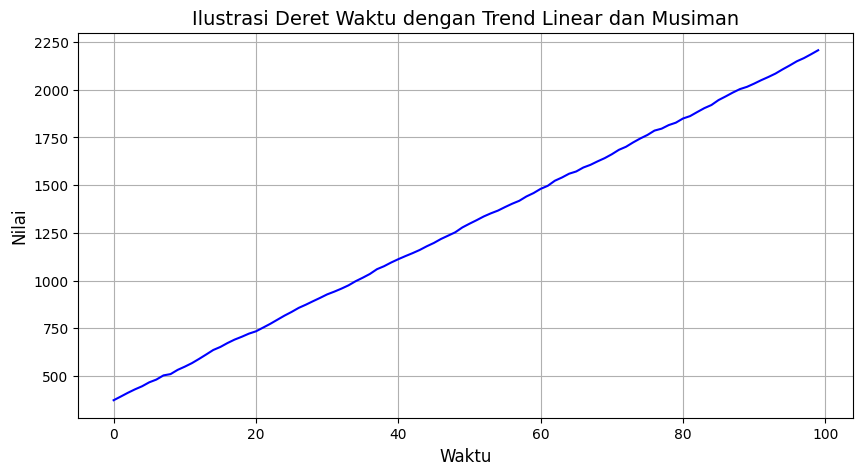

In [78]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [79]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [80]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [81]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.972e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.61e-205
Time:                        14:51:34   Log-Likelihood:                -213.11
No. Observations:                 100   AIC:                             452.2
Df Residuals:                      87   BIC:                             486.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      369.5930      0.814    453.795      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

Karena model tidak menggunakan intersep terpisah dan memasukkan 12 dummy bulan, maka koefisien setiap bulan menunjukkan nilai dasar untuk bulan tersebut setelah memperhitungkan komponen tren. Dengan kata lain, koefisien bulan menggambarkan level masing-masing bulan ketika komponen waktu dikendalikan, sedangkan perbedaan antar koefisien bulan menunjukkan pola musimannya.

Koefisien `period` sebesar 18.4962 menunjukkan bahwa setiap bertambah satu periode waktu, nilai deret meningkat sekitar 18.4962 satuan dengan pola musiman dianggap tetap. Nilai ini sangat dekat dengan parameter tren asli yang digunakan dalam simulasi, yaitu 18.5.

Koefisien bulan menunjukkan pola musiman yang berbeda antarbulan. Koefisien Januari sebesar 369.5930, Februari sebesar 372.6085, dan Maret sebesar 374.8282. Nilai koefisien relatif tinggi pada April sebesar 374.6661 dan mencapai nilai tertinggi pada Mei sebesar 375.0879. Setelah itu, nilai koefisien cenderung menurun hingga mencapai nilai terendah pada Oktober sebesar 364.6595, kemudian kembali meningkat pada November sebesar 366.7883 dan Desember sebesar 368.0248. Pola perubahan koefisien tersebut menunjukkan adanya komponen musiman yang berulang setiap 12 periode.

Secara umum, model mampu menangkap dua komponen sekaligus, yaitu tren linear yang meningkat dari waktu ke waktu dan pola musiman yang berbeda antarbulan. Hasil pendugaan koefisien `period` yang sangat dekat dengan nilai parameter asli juga menunjukkan bahwa model mampu menangkap komponen tren linear dengan baik.

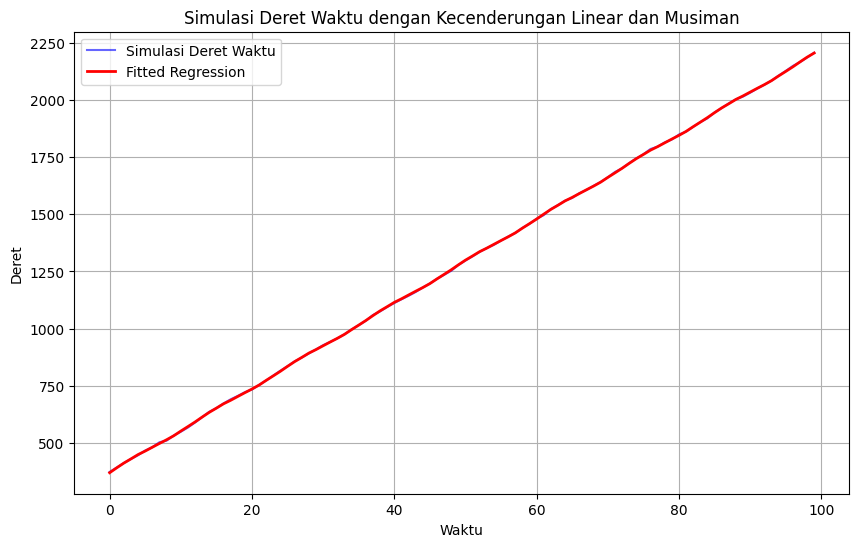

In [82]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [83]:
# uji asumsi model


from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# Residual model
resid_mix = model_mix.resid


# 1. Uji Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(resid_mix)

print("Uji Shapiro-Wilk")
print(f"Statistic = {shapiro_stat:.4f}")
print(f"p-value = {shapiro_p:.4f}")


# 2. Uji Breusch-Pagan
# 11 dummy bulan + period + konstanta
X_bp = sm.add_constant(season.iloc[:, 1:])

bp_test = het_breuschpagan(resid_mix, X_bp)

print("\nUji Breusch-Pagan")
print(f"LM Statistic = {bp_test[0]:.4f}")
print(f"p-value = {bp_test[1]:.4f}")


# 3. Uji Ljung-Box sampai lag ke-12
ljung_test = acorr_ljungbox(
    resid_mix,
    lags=[12],
    return_df=True
)

print("\nUji Ljung-Box")
print(ljung_test)


# 4. Durbin-Watson
dw = durbin_watson(resid_mix)

print("\nDurbin-Watson")
print(f"Statistic = {dw:.4f}")

Uji Shapiro-Wilk
Statistic = 0.9883
p-value = 0.5317

Uji Breusch-Pagan
LM Statistic = 15.9897
p-value = 0.1917

Uji Ljung-Box
      lb_stat  lb_pvalue
12  17.104845   0.145696

Durbin-Watson
Statistic = 1.8043


Berdasarkan uji Shapiro-Wilk diperoleh nilai statistik sebesar 0,9883 dan $p\text{-value} = 0,5317$. Karena $p\text{-value} > 0,05$, maka $H_0$ tidak ditolak. Hal ini menunjukkan bahwa tidak terdapat bukti yang cukup bahwa residual menyimpang dari distribusi normal, sehingga asumsi normalitas residual dapat dikatakan terpenuhi.

Berdasarkan uji Breusch-Pagan diperoleh nilai LM Statistic sebesar 15,9897 dan $p\text{-value} = 0,1917$. Karena $p\text{-value} > 0,05$, maka $H_0$ tidak ditolak, sehingga tidak terdapat indikasi heteroskedastisitas. Dengan demikian, asumsi homoskedastisitas dapat dikatakan terpenuhi.

Berdasarkan uji Ljung-Box pada lag ke-12 diperoleh nilai statistik sebesar 17,1048 dan $p\text{-value} = 0,1457$. Karena $p\text{-value} > 0,05$, maka $H_0$ tidak ditolak, sehingga tidak terdapat indikasi autokorelasi residual sampai lag ke-12. Hal ini menunjukkan bahwa komponen tren linear dan pola musiman dengan periode 12 sudah cukup terakomodasi oleh model.

Nilai Durbin-Watson sebesar 1,8043 juga cukup mendekati 2, sehingga tidak terdapat indikasi autokorelasi orde pertama yang kuat.

Secara keseluruhan, hasil pengujian tidak menunjukkan adanya pelanggaran asumsi normalitas, homoskedastisitas, maupun independensi residual. Model regresi yang memuat komponen tren linear dan musiman sudah cukup sesuai untuk menggambarkan deret waktu tersebut.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [84]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

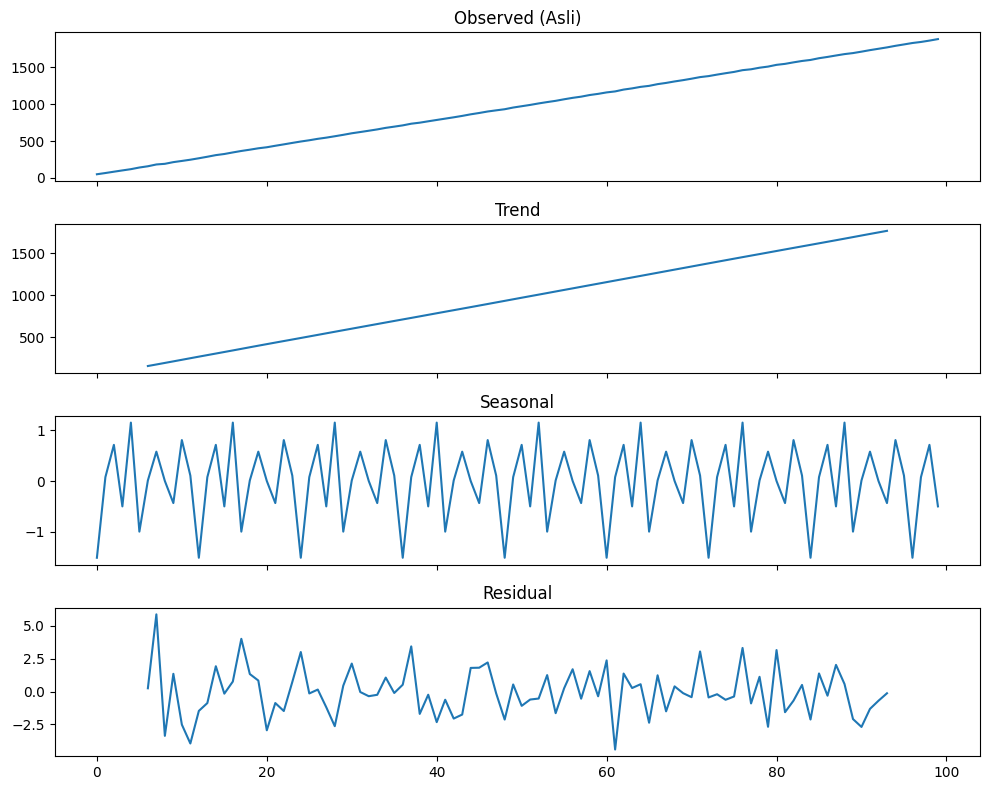

In [85]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi, komponen *observed* menunjukkan bahwa nilai deret meningkat secara relatif konsisten dari waktu ke waktu. Pola tersebut menunjukkan adanya kecenderungan linear yang cukup kuat pada deret.

Komponen *trend* juga memperlihatkan pola meningkat yang hampir linear. Hal ini menunjukkan bahwa perubahan jangka panjang pada deret terutama dijelaskan oleh komponen tren.

Komponen *seasonal* menunjukkan pola naik dan turun yang berulang setiap 12 periode. Namun, besar fluktuasi komponen musiman relatif sangat kecil dibandingkan dengan perubahan pada komponen tren. Oleh karena itu, komponen musiman pada deret ini tidak terlalu dominan. Pola tersebut dapat muncul karena proses dekomposisi dilakukan dengan menetapkan periode musiman sebesar 12.

Komponen *residual* berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu yang jelas. Hal ini menunjukkan bahwa setelah komponen tren dan musiman dipisahkan, variasi yang tersisa sebagian besar merupakan variasi acak atau noise.

Hasil dekomposisi menunjukkan bahwa komponen yang paling dominan pada deret adalah tren linear sedangkan komponen musiman relatif kecil dan residual bersifat acak. Hasil ini sesuai dengan proses simulasi deret yang memang dibentuk terutama oleh kecenderungan linear dan noise acak.

In [86]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

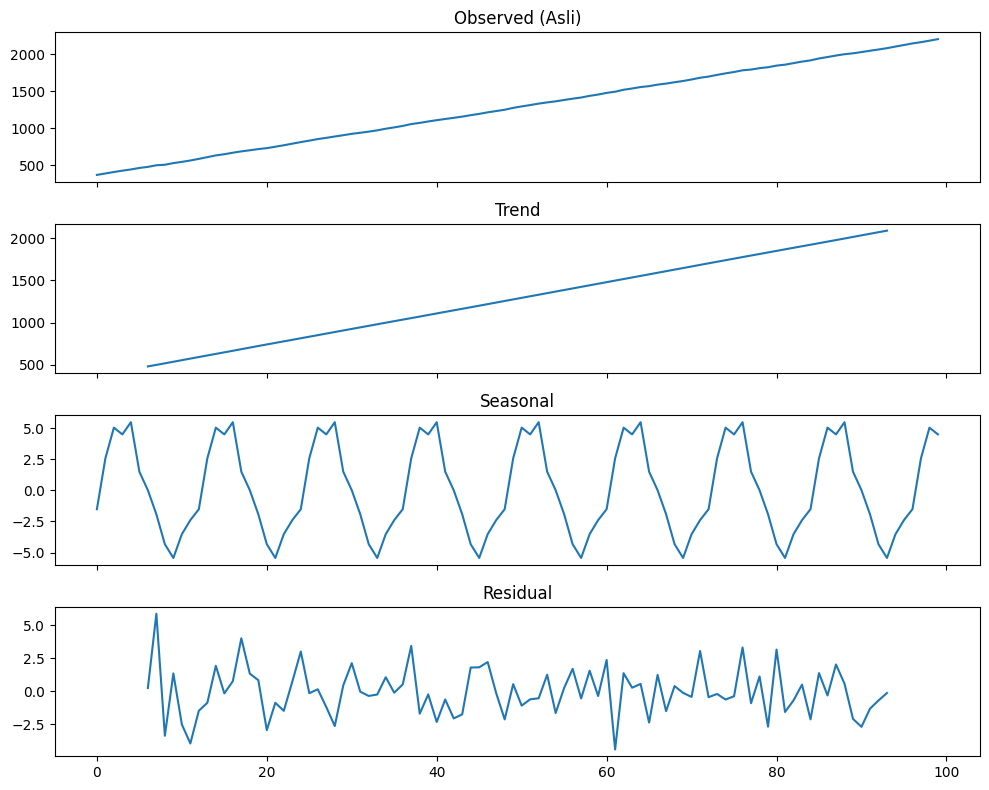

In [87]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi, komponen *observed* menunjukkan bahwa nilai deret meningkat dari waktu ke waktu dengan pola yang relatif linear. Di dalam pola kenaikan tersebut juga terdapat fluktuasi kecil yang berulang secara teratur.

Komponen *trend* menunjukkan kecenderungan meningkat secara linear. Hal ini menunjukkan bahwa perubahan jangka panjang pada deret didominasi oleh tren naik.

Komponen *seasonal* menunjukkan pola naik dan turun yang berulang secara teratur setiap 12 periode. Besarnya fluktuasi musiman relatif stabil dari waktu ke waktu, sehingga pola musiman yang terbentuk sesuai dengan komponen musiman yang digunakan dalam simulasi.

Komponen *residual* berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu yang jelas. Hal ini menunjukkan bahwa setelah komponen tren dan musiman dipisahkan, variasi yang tersisa sebagian besar merupakan variasi acak atau noise.

Secara keseluruhan, hasil dekomposisi menunjukkan bahwa deret memiliki dua komponen utama, yaitu tren linear yang meningkat dan pola musiman dengan periode 12. Residual yang tersisa relatif acak, sehingga dekomposisi sudah mampu memisahkan komponen utama deret dengan cukup baik.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [88]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1037)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05*37, 10*37 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

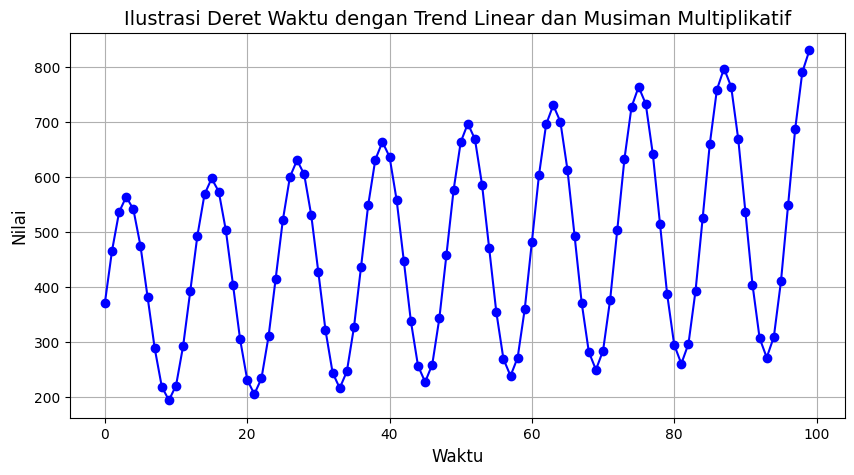

In [89]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [90]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

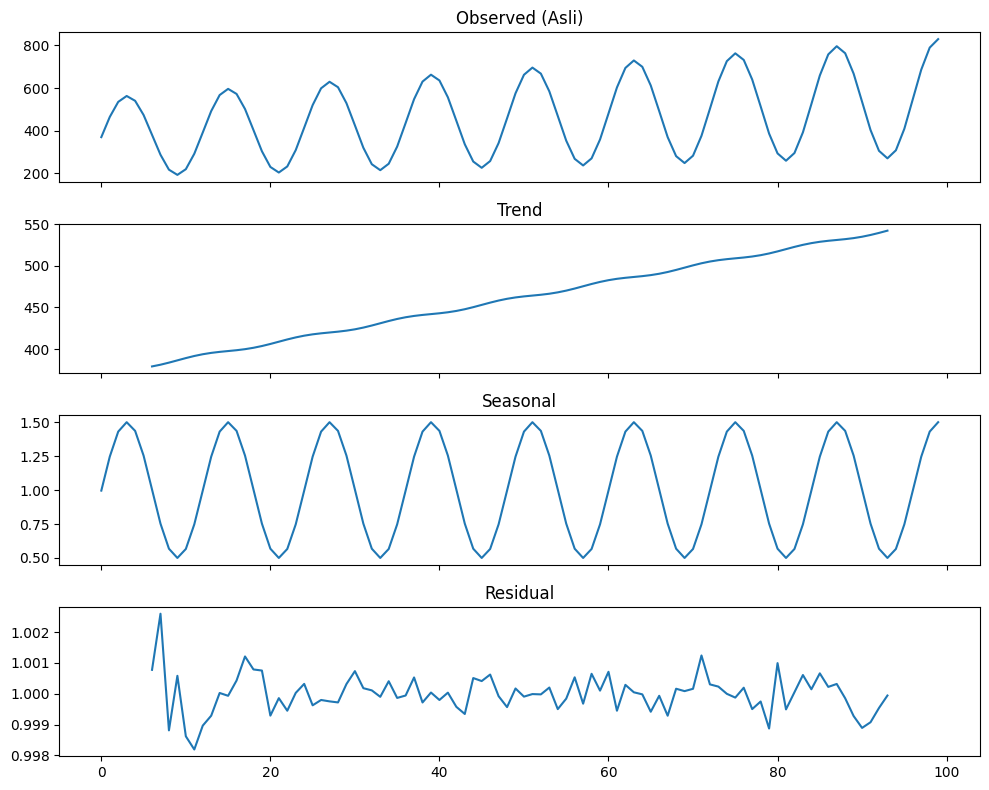

In [91]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

Berdasarkan hasil dekomposisi, komponen *observed* menunjukkan bahwa nilai deret memiliki kecenderungan meningkat dari waktu ke waktu dan disertai pola naik turun yang berulang secara teratur. Besarnya fluktuasi musiman juga semakin besar seiring meningkatnya level deret, sehingga pola tersebut sesuai dengan karakteristik model multiplikatif.

Komponen *trend* menunjukkan kecenderungan meningkat secara bertahap sepanjang waktu. Hal ini menunjukkan bahwa deret memiliki tren jangka panjang yang positif.

Komponen *seasonal* menunjukkan pola yang berulang setiap 12 periode. Nilai komponen musiman berfluktuasi di sekitar 1, yaitu kurang lebih antara 0,5 sampai 1,5. Pada model multiplikatif, nilai di atas 1 menunjukkan bahwa komponen musiman meningkatkan level deret, sedangkan nilai di bawah 1 menunjukkan bahwa komponen musiman menurunkan level deret.

Komponen *residual* berfluktuasi di sekitar nilai 1 dan tidak menunjukkan pola tertentu yang jelas. Hal ini menunjukkan bahwa setelah komponen tren dan musiman dipisahkan, variasi yang tersisa relatif kecil dan bersifat acak.

Secara keseluruhan, hasil dekomposisi menunjukkan bahwa deret memiliki tren yang meningkat dan pola musiman dengan periode 12 yang besarnya berubah mengikuti level deret. Residual yang relatif kecil dan menyebar di sekitar 1 menunjukkan bahwa model dekomposisi multiplikatif cukup baik dalam memisahkan komponen utama deret.

In [92]:
# Parameter
np.random.seed(1037)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

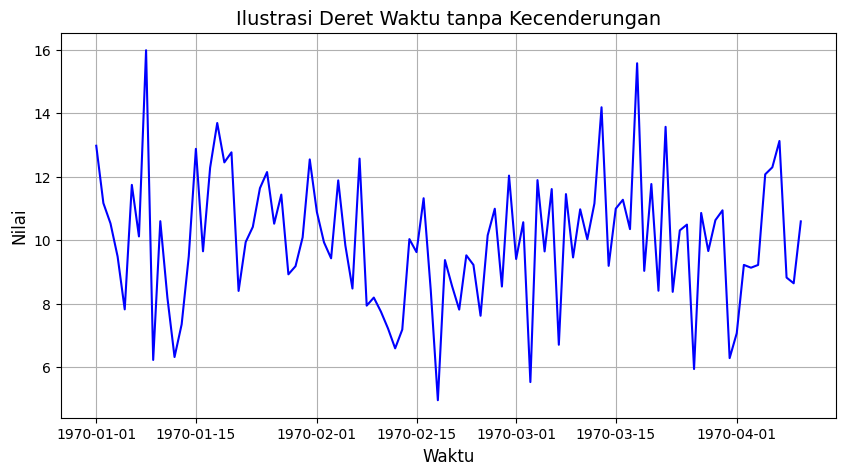

In [93]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

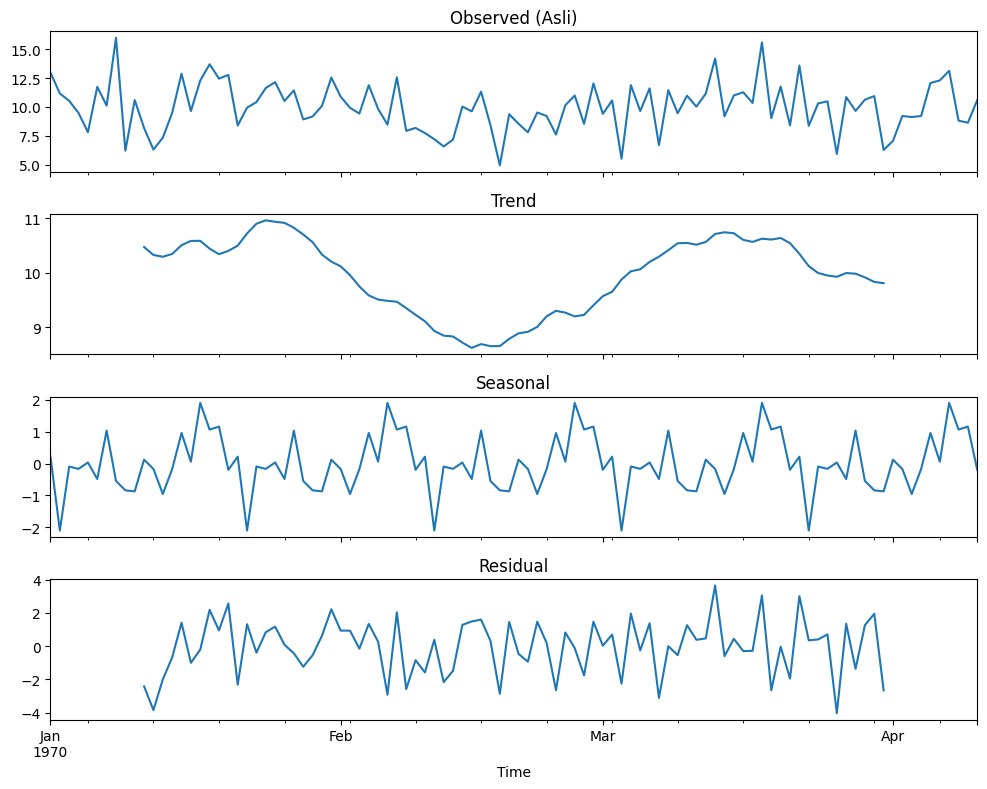

In [94]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

Berdasarkan hasil dekomposisi, komponen *observed* menunjukkan bahwa nilai deret berfluktuasi secara acak di sekitar level yang relatif tetap dan tidak menunjukkan kecenderungan meningkat atau menurun secara sistematis.

Komponen *trend* terlihat mengalami sedikit naik dan turun, tetapi perubahan tersebut tidak membentuk kecenderungan jangka panjang yang jelas. Pola ini lebih merupakan hasil pemulusan dari variasi acak pada data.

Komponen *seasonal* menunjukkan pola yang berulang setiap 20 periode. Namun, besar fluktuasinya relatif kecil dan pola tersebut muncul karena proses dekomposisi dilakukan dengan menetapkan periode sebesar 20. Oleh karena itu, pola tersebut tidak dapat langsung diartikan sebagai adanya komponen musiman yang kuat pada deret.

Komponen *residual* masih menunjukkan fluktuasi acak di sekitar nilai nol dan tidak membentuk pola tertentu yang jelas. Hal ini sesuai dengan proses pembangkitan data yang memang hanya terdiri atas noise acak.

Secara keseluruhan, hasil dekomposisi menunjukkan bahwa deret tidak memiliki tren maupun pola musiman yang kuat. Komponen utama deret adalah variasi acak, sedangkan pola pada komponen trend dan seasonal lebih banyak muncul akibat proses dekomposisi yang diterapkan pada data.